# LiRPA refinement ablation

Comparison of the same Eq. (1) anchor neighborhoods under geometry-only projection, targeted PGD, and CertCF refinement. Quality metrics are shown both on each method's successes and on paired successes.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = ROOT / 'results' / 'lirpa_refinement_ablation'
queries = pd.read_parquet(RESULTS / 'lirpa_refinement_queries.parquet')
summary = pd.read_parquet(RESULTS / 'lirpa_refinement_summary.parquet')
empirical = pd.read_parquet(RESULTS / 'empirical_robustness.parquet')
assert not queries.duplicated(['case_id', 'query_position', 'method']).any()
queries.shape, summary.shape

((3811, 304), (12, 23))

## Completion and all-query outcomes

In [2]:
completion = (queries.groupby(['case_id', 'method'])
              .agg(rows=('query_position', 'size'), success_pct=('success', lambda x: 100*x.mean()),
                   timeout_pct=('timed_out', lambda x: 100*x.mean()),
                   feasibility_pct=('domain_feasible', lambda x: 100*x.mean()))
              .reset_index())
completion

,case_id,method,rows,success_pct,timeout_pct,feasibility_pct
0,adult,anchor_ball,500,90.6,0.0,100.0
1,adult,anchor_pgd,500,100.0,0.0,100.0
2,adult,certcf,500,100.0,0.0,100.0
3,depth_01_width_128,anchor_ball,500,96.0,0.0,100.0
4,depth_01_width_128,anchor_pgd,111,100.0,0.0,100.0
5,depth_01_width_128,certcf,50,100.0,0.0,100.0
6,depth_05_width_128,anchor_ball,50,96.0,0.0,100.0
7,depth_05_width_128,anchor_pgd,50,100.0,0.0,100.0
8,depth_05_width_128,certcf,50,100.0,0.0,100.0
9,heloc,anchor_ball,500,73.6,0.0,100.0


## Per-case benchmark table

In [3]:
columns = ['case_id', 'method', 'success_rate', 'timeout_rate', 'mean_l1', 'mean_l2',
           'mean_l0', 'mean_mad_l1', 'mean_redundancy', 'mean_log10_lof', 'mean_isolation_forest_score',
           'empirical_target_rate', 'mean_certified_l1_radius',
           'mean_runtime_seconds', 'mean_certcf_to_pgd_l1_ratio']
summary[[c for c in columns if c in summary]].sort_values(['case_id', 'method'])

,case_id,method,success_rate,timeout_rate,mean_l1,mean_l2,mean_l0,mean_mad_l1,mean_redundancy,mean_log10_lof,mean_isolation_forest_score,empirical_target_rate,mean_certified_l1_radius,mean_runtime_seconds,mean_certcf_to_pgd_l1_ratio
0,adult,anchor_ball,0.906,0.0,5.990775,2.507500,6.896,0.077464,0.564991,0.047448,-0.381997,0.976600,NaN,0.056672,1.023008
1,adult,anchor_pgd,1.000,0.0,6.195079,2.576464,6.950,0.081609,0.544294,0.046828,-0.381086,0.957880,NaN,17.262816,1.023008
2,adult,certcf,1.000,0.0,6.314760,2.601206,6.982,0.083261,0.547599,0.044087,-0.379946,0.960640,NaN,0.062762,1.023008
3,depth_01_width_128,anchor_ball,0.960,0.0,21.255348,5.213048,32.000,0.987721,0.962370,0.004660,-0.409972,0.996167,NaN,0.006958,1.092325
4,depth_01_width_128,anchor_pgd,1.000,0.0,21.596734,5.307914,32.000,1.003389,0.940878,0.004973,-0.410368,0.985405,NaN,6.295456,1.092325
5,depth_01_width_128,certcf,1.000,0.0,23.627836,5.609512,32.000,1.097752,0.963750,0.003049,-0.408943,0.992800,NaN,0.009341,1.092325
6,depth_05_width_128,anchor_ball,0.960,0.0,21.450981,5.299395,32.000,0.996900,0.980469,0.004587,-0.406994,0.999583,NaN,0.006983,1.139261
7,depth_05_width_128,anchor_pgd,1.000,0.0,21.450980,5.353875,32.000,0.996896,0.958125,0.005105,-0.407472,0.991200,NaN,8.065653,1.139261
8,depth_05_width_128,certcf,1.000,0.0,24.388133,5.726281,32.000,1.133287,0.978750,0.002965,-0.405857,0.998400,NaN,0.009447,1.139261
9,heloc,anchor_ball,0.736,0.0,10.280622,3.188932,16.178,1.212376,0.752269,0.024304,-0.413749,0.940543,NaN,0.010434,1.083695


## Paired quality on shared successes

In [4]:
quality_metrics = ['l1_distance', 'l2_distance', 'l0_changed', 'mad_l1_distance', 'redundancy', 'log10_lof',
                   'isolation_forest_score', 'certified_l1_radius', 'runtime_seconds']
paired_all = (queries[queries.shared_success_all]
              .groupby(['case_id', 'method'])[quality_metrics].mean().reset_index())
paired_pgd_certcf = (queries[queries.method.isin(['anchor_pgd', 'certcf']) &
                              queries.shared_success_pgd_certcf.fillna(False)]
                     .groupby(['case_id', 'method'])[quality_metrics].mean().reset_index())
display(paired_all)
display(paired_pgd_certcf)

,case_id,method,l1_distance,l2_distance,l0_changed,mad_l1_distance,redundancy,log10_lof,isolation_forest_score,certified_l1_radius,runtime_seconds
0,adult,anchor_ball,5.889361,2.483765,6.812362,0.075622,0.564991,0.047448,-0.381997,NaN,0.056762
1,adult,anchor_pgd,6.094849,2.550411,6.883002,0.079716,0.577897,0.044835,-0.380601,NaN,16.908131
2,adult,certcf,6.217245,2.576910,6.909492,0.081386,0.579154,0.041574,-0.379396,NaN,0.062784
3,depth_01_width_128,anchor_ball,21.976825,5.335194,32.000000,1.020920,0.942361,0.003607,-0.408920,NaN,0.006802
4,depth_01_width_128,anchor_pgd,21.976824,5.386511,32.000000,1.020925,0.935417,0.003676,-0.409205,NaN,6.221227
5,depth_01_width_128,certcf,23.854411,5.675375,32.000000,1.108261,0.979167,0.003016,-0.409818,NaN,0.009340
6,depth_05_width_128,anchor_ball,21.470840,5.310752,32.000000,0.997713,0.980469,0.004587,-0.406994,NaN,0.006990
7,depth_05_width_128,anchor_pgd,21.470838,5.364583,32.000000,0.997707,0.980469,0.004878,-0.407519,NaN,8.048915
8,depth_05_width_128,certcf,24.386933,5.731151,32.000000,1.133110,0.986979,0.002338,-0.405511,NaN,0.009442
9,heloc,anchor_ball,11.201717,3.414094,16.342391,1.333502,0.752269,0.024304,-0.413749,NaN,0.010430


,case_id,method,l1_distance,l2_distance,l0_changed,mad_l1_distance,redundancy,log10_lof,isolation_forest_score,certified_l1_radius,runtime_seconds
0,adult,anchor_pgd,6.195079,2.576464,6.950,0.081609,0.544294,0.046828,-0.381086,NaN,17.262816
1,adult,certcf,6.314760,2.601206,6.982,0.083261,0.547599,0.044087,-0.379946,NaN,0.062762
2,depth_01_width_128,anchor_pgd,21.671631,5.308806,32.000,1.006818,0.907500,0.003387,-0.408502,NaN,6.212937
3,depth_01_width_128,certcf,23.627836,5.609512,32.000,1.097752,0.963750,0.003049,-0.408943,NaN,0.009341
4,depth_05_width_128,anchor_pgd,21.450980,5.353875,32.000,0.996896,0.958125,0.005105,-0.407472,NaN,8.065653
5,depth_05_width_128,certcf,24.388133,5.726281,32.000,1.133287,0.978750,0.002965,-0.405857,NaN,0.009447
6,heloc,anchor_pgd,10.280621,3.211460,16.178,1.211451,0.661530,0.024080,-0.412452,NaN,10.934243
7,heloc,certcf,10.945570,3.366011,16.108,1.295031,0.781910,0.022149,-0.410141,NaN,0.013911


## Synthetic32 depth trends

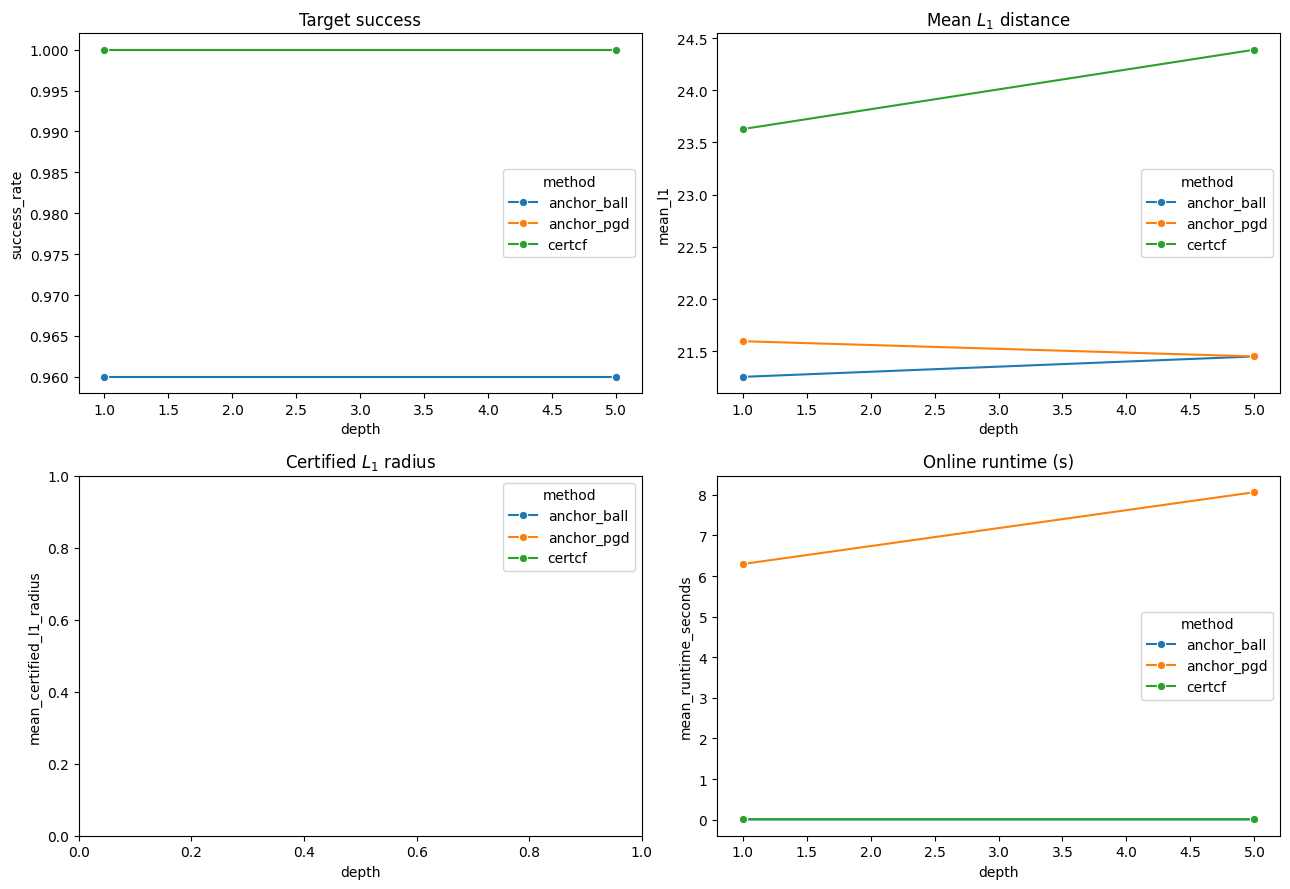

In [5]:
synthetic = summary[summary.kind == 'synthetic32'].copy()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for metric, axis, title in [
    ('success_rate', axes[0,0], 'Target success'),
    ('mean_l1', axes[0,1], 'Mean $L_1$ distance'),
    ('mean_certified_l1_radius', axes[1,0], 'Certified $L_1$ radius'),
    ('mean_runtime_seconds', axes[1,1], 'Online runtime (s)')]:
    sns.lineplot(data=synthetic, x='depth', y=metric, hue='method', marker='o', ax=axis)
    axis.set_title(title)
plt.tight_layout()

## Robustness curves

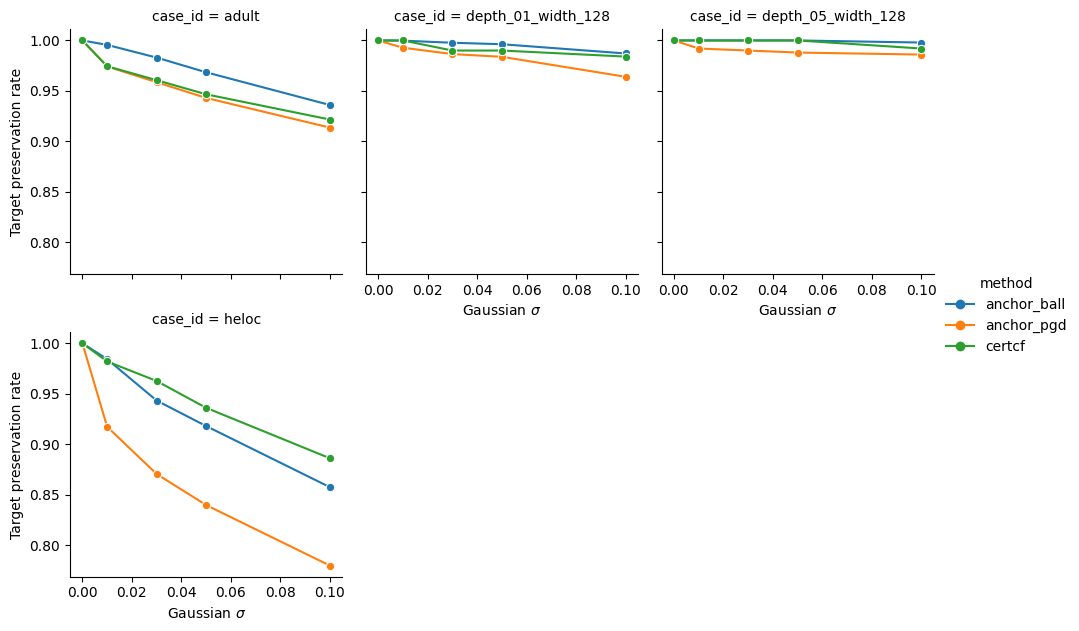

In [6]:
curves = empirical.groupby(['case_id', 'method', 'sigma']).target_rate.mean().reset_index()
grid = sns.relplot(data=curves, x='sigma', y='target_rate', hue='method',
                   col='case_id', col_wrap=3, kind='line', marker='o', height=3.2)
grid.set_axis_labels('Gaussian $\sigma$', 'Target preservation rate')

## Failure and resource diagnostics

In [7]:
failure_breakdown = (queries[~queries.success]
                     .assign(reason=lambda d: np.where(d.timed_out, 'timeout',
                         np.where(~d.candidate_found, 'no candidate',
                         np.where(~d.domain_feasible, 'infeasible', 'wrong target'))))
                     .groupby(['case_id', 'method', 'reason']).size()
                     .rename('count').reset_index())
display(failure_breakdown)
build_rows = []
for path in sorted((RESULTS / 'cases').glob('*/certcf/build.json')):
    build_rows.append(json.loads(path.read_text()))
builds = pd.DataFrame(build_rows)
builds

,case_id,method,reason,count
0,adult,anchor_ball,wrong target,47
1,depth_01_width_128,anchor_ball,wrong target,20
2,depth_05_width_128,anchor_ball,wrong target,2
3,heloc,anchor_ball,wrong target,132


,adaptive_shrinks_mean,atlas_region_count,attempted_anchor_count,build_cuda_peak_allocated_bytes,build_cuda_peak_reserved_bytes,build_rss_baseline_bytes,build_rss_peak_bytes,build_rss_peak_delta_bytes,build_rss_sample_count,build_wall_time_s,case_id,eps_final_median,eps_initial_median,eps_retention_median,run_fingerprint,status
0,0.851,1000,1000,9717248,23068672,1712705536,1732239360,19533824,508,25.559957,adult,0.465617,0.906411,0.50,dc83e9c2a7298c74679b45f690c662c65193183ad96a24...,complete
1,0.948,1000,1000,9695744,23068672,1685139456,1698590720,13451264,312,15.737792,depth_01_width_128,2.298991,4.567395,0.50,51cc0170f63e0ab22ce20b5e85616ed62a23146d13befe...,complete
2,1.184,1000,1000,9860096,23068672,1042784256,1621528576,578744320,854,43.070322,depth_02_width_128,2.194940,4.492515,0.50,b631d6b5039779c91113a775d3b42a0425aaf3ac5af1d4...,complete
3,1.551,1000,1000,10075136,23068672,1624944640,1624944640,0,1561,78.557288,depth_03_width_128,1.348465,4.529958,0.25,05ab7189ee278b570553a7a98c93cd002c40a97cfcdcb1...,complete
4,1.799,1000,1000,10273280,25165824,1625538560,1625538560,0,2347,118.099359,depth_04_width_128,1.190861,4.528123,0.25,7947b1c32edeec4328305b54beb4d7ea62f6fe7071b066...,complete
5,1.985,1000,1000,10505216,25165824,1698586624,1698586624,0,3280,165.222895,depth_05_width_128,1.135431,4.499973,0.25,3df1f3dcfacd753ec7cff1c1807cf63b4e7033fec22fdc...,complete
6,0.988,1000,1000,9627648,27262976,1252044800,1670516736,418471936,542,27.322529,heloc,0.770594,1.452589,0.50,85a399d5fd46eb2bd755bd8849548dd9ae2e5b8a51062a...,complete
